# 18. AI for Quasi-Experiment Design

A quasi-experiment is what we reach for when a randomized experiment is infeasible, unethical, too slow, already missed, or blocked by product constraints. The analyst's job is not to make observational data sound experimental. The job is to find a credible source of quasi-random variation and then make the assumptions testable enough to argue about.

This notebook shows how AI can help brainstorm and critique quasi-experimental designs, while deterministic code performs the actual diagnostics. We will focus on an industry rollout setting where a support AI assistant is deployed to some queues before others.

## Learning Goals

By the end of this notebook you should be able to:

1. Identify when DiD, event study, RDD, IV, or synthetic control might be appropriate.
2. Convert a business rollout story into a quasi-experiment design contract.
3. Simulate a staged rollout and estimate a difference-in-differences model.
4. Diagnose pre-trends, placebo effects, anticipation risk, and comparison-group quality.
5. Build a small regression-discontinuity diagnostic around a cutoff assignment rule.
6. Write a machine-readable quasi-experiment design report.
7. Use local LLMs to critique design credibility while auditing them for overclaiming.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Quasi-experiment notebooks are particularly brittle because the identifying assumptions are qualitative and design-specific. A model can correctly name "difference-in-differences" while ignoring non-parallel pre-trends, endogenous timing, manipulation near a cutoff, spillovers, or bad comparison groups. We will keep the LLM in a reviewer role and score it against deterministic diagnostics.

## 1. Setup

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'
LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_STRONG_MODEL
MAX_NEW_TOKENS = 1900
TEMPERATURE = 0.0
SEED = 218
MODEL_COMPARISON_CASE_LIMIT = 2

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 160)

In [3]:
def has_package(module_name):
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'panel and diagnostic tables'},
        {'package': 'numpy', 'available': has_package('numpy'), 'used_for': 'simulation'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'DiD, event-study, and RDD regressions'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'diagnostic plots'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI quasi-experiment review'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
package_status

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,panel and diagnostic tables
1,numpy,True,simulation
2,statsmodels,True,"DiD, event-study, and RDD regressions"
3,seaborn,True,diagnostic plots
4,pydantic,True,structured AI quasi-experiment review
5,transformers,True,optional local LLM review
6,torch,True,GPU inference if live LLMs are enabled


## 2. What Makes a Quasi-Experiment Credible?

A quasi-experiment needs a design story, not just a regression formula. The design story explains why the treatment changed for some units but not others in a way that can plausibly reveal a causal effect.

Common designs include:

- **Difference-in-differences:** treated and comparison units would have followed parallel trends absent treatment.
- **Event study:** treatment timing creates leads and lags that can test pre-trends and dynamic effects.
- **Regression discontinuity:** units near a cutoff are comparable except for treatment assignment.
- **Instrumental variables:** an instrument changes treatment but affects the outcome only through treatment.
- **Synthetic control:** a weighted combination of untreated units approximates the treated unit's pre-period path.

AI can help list candidates. It cannot certify the assumptions.

In [4]:
design_catalog = pd.DataFrame(
    [
        {
            'design': 'Difference-in-differences',
            'variation needed': 'A rollout, policy change, or shock affects some units earlier or more than others.',
            'core assumption': 'Parallel trends absent treatment.',
            'must check': 'Pre-trends, compositional changes, spillovers, endogenous timing.',
        },
        {
            'design': 'Event study',
            'variation needed': 'Treatment timing varies across units or cohorts.',
            'core assumption': 'No anticipatory jumps and credible counterfactual trends.',
            'must check': 'Lead coefficients, dynamic lag pattern, treatment timing selection.',
        },
        {
            'design': 'Regression discontinuity',
            'variation needed': 'A deterministic or fuzzy cutoff changes treatment probability.',
            'core assumption': 'Continuity of potential outcomes at the cutoff.',
            'must check': 'Density manipulation, covariate continuity, bandwidth sensitivity.',
        },
        {
            'design': 'Instrumental variables',
            'variation needed': 'An external source shifts treatment take-up.',
            'core assumption': 'Relevance, exclusion, independence, monotonicity.',
            'must check': 'First stage, exclusion threats, direct effects, weak instrument risk.',
        },
        {
            'design': 'Synthetic control',
            'variation needed': 'A treated aggregate unit and many untreated donor units over time.',
            'core assumption': 'Weighted donor pool approximates untreated treated-unit trajectory.',
            'must check': 'Pre-period fit, donor quality, placebo units, post-period shocks.',
        },
    ]
)
design_catalog

,design,variation needed,core assumption,must check
0,Difference-in-differences,"A rollout, policy change, or shock affects some units earlier or more than others.",Parallel trends absent treatment.,"Pre-trends, compositional changes, spillovers, endogenous timing."
1,Event study,Treatment timing varies across units or cohorts.,No anticipatory jumps and credible counterfactual trends.,"Lead coefficients, dynamic lag pattern, treatment timing selection."
2,Regression discontinuity,A deterministic or fuzzy cutoff changes treatment probability.,Continuity of potential outcomes at the cutoff.,"Density manipulation, covariate continuity, bandwidth sensitivity."
3,Instrumental variables,An external source shifts treatment take-up.,"Relevance, exclusion, independence, monotonicity.","First stage, exclusion threats, direct effects, weak instrument risk."
4,Synthetic control,A treated aggregate unit and many untreated donor units over time.,Weighted donor pool approximates untreated treated-unit trajectory.,"Pre-period fit, donor quality, placebo units, post-period shocks."


### Discussion

A good AI assistant should ask for the assignment mechanism. "We have treated and control groups" is not enough. The credibility of the design depends on why those groups differ, when treatment began, whether the comparison group is exposed indirectly, and whether the outcome was already trending differently before treatment.

## 3. Running Example: Staged AI Support Assistant Rollout

A company deploys an AI assistant that drafts responses for support agents. The deployment is staged by support queue. Some queues receive the assistant in week 0; other queues stay on the standard workflow.

The business question is:

> What is the effect of enabling the AI support assistant on tickets resolved per agent-hour?

The proposed design is a difference-in-differences/event-study analysis using queue-week panel data.

In [5]:
quasi_contract = {
    'analysis_id': 'ai_support_staged_rollout_did_v1',
    'business_question': 'What is the effect of enabling an AI support assistant on tickets resolved per agent-hour?',
    'candidate_design': 'difference-in-differences with event-study diagnostics',
    'unit': 'support_queue_week',
    'treated_unit': 'support queue',
    'treatment': 'assistant enabled for first-draft support responses',
    'comparison': 'queues not yet enabled during the same calendar weeks',
    'time_zero': 'first week the assistant is enabled for treated queues',
    'primary_outcome': 'tickets_resolved_per_agent_hour',
    'guardrail_outcomes': ['escalation_rate', 'csat_score'],
    'pre_period_weeks': 16,
    'post_period_weeks': 14,
    'key_assumption': 'treated and comparison queues would have followed parallel trends absent assistant enablement',
    'known_risks': [
        'Queues were prioritized partly by operational readiness.',
        'Agents may move across queues and create spillovers.',
        'Seasonality and ticket mix can differ by queue.',
        'AI-generated design summaries may overstate credibility if pre-trend diagnostics look acceptable in one simulation only.',
    ],
}

print(json.dumps(quasi_contract, indent=2))

{
  "analysis_id": "ai_support_staged_rollout_did_v1",
  "business_question": "What is the effect of enabling an AI support assistant on tickets resolved per agent-hour?",
  "candidate_design": "difference-in-differences with event-study diagnostics",
  "unit": "support_queue_week",
  "treated_unit": "support queue",
  "treatment": "assistant enabled for first-draft support responses",
  "comparison": "queues not yet enabled during the same calendar weeks",
  "time_zero": "first week the assistant is enabled for treated queues",
  "primary_outcome": "tickets_resolved_per_agent_hour",
  "guardrail_outcomes": [
    "escalation_rate",
    "csat_score"
  ],
  "pre_period_weeks": 16,
  "post_period_weeks": 14,
  "key_assumption": "treated and comparison queues would have followed parallel trends absent assistant enablement",
  "known_risks": [
    "Queues were prioritized partly by operational readiness.",
    "Agents may move across queues and create spillovers.",
    "Seasonality and tick

## 4. Simulating a Queue-Week Panel

We simulate queue-week data with queue fixed effects, week fixed effects, ticket-mix changes, and a treatment effect that appears after rollout. The simulation has a known truth, but the analysis behaves as if the counterfactual treated outcomes are unobserved.

In [6]:
def simulate_support_rollout(
    n_queues=72,
    pre_weeks=16,
    post_weeks=14,
    treated_share=0.45,
    treatment_effect=0.34,
    pretrend_gap=0.0,
    anticipation_effect=0.0,
    seed=SEED,
):
    rng = np.random.default_rng(seed)
    queues = np.arange(n_queues)
    weeks = np.arange(-pre_weeks, post_weeks + 1)
    treated_queue = rng.binomial(1, treated_share, size=n_queues)
    queue_size = rng.lognormal(mean=2.25, sigma=0.35, size=n_queues)
    readiness = rng.normal(0, 1, size=n_queues) + 0.35 * treated_queue
    queue_fe = rng.normal(0, 0.45, size=n_queues) + 0.25 * readiness
    baseline_complexity = rng.normal(0, 1, size=n_queues)

    rows = []
    for q in queues:
        for week in weeks:
            post = int(week >= 0)
            treated_post = int(treated_queue[q] == 1 and post == 1)
            anticipation = int(treated_queue[q] == 1 and week in [-2, -1])
            common_time = 0.035 * week + 0.20 * np.sin((week + pre_weeks) / 4)
            treated_pretrend = pretrend_gap * treated_queue[q] * week / pre_weeks if week < 0 else 0.0
            complexity = baseline_complexity[q] + 0.04 * week + rng.normal(0, 0.20)
            staffing = queue_size[q] + 0.08 * readiness[q] + rng.normal(0, 0.15)
            untreated_potential = (
                4.3
                + queue_fe[q]
                + common_time
                - 0.18 * complexity
                + 0.12 * staffing
                + treated_pretrend
                + rng.normal(0, 0.30)
            )
            dynamic_effect = treatment_effect * treated_post * (1 - np.exp(-max(week, 0) / 4))
            outcome = untreated_potential + dynamic_effect + anticipation_effect * anticipation
            escalation_rate = 0.20 - 0.014 * treated_post + 0.018 * complexity + rng.normal(0, 0.015)
            csat_score = 4.05 + 0.04 * treated_post - 0.08 * complexity + rng.normal(0, 0.08)
            rows.append(
                {
                    'queue_id': f'q{q:03d}',
                    'week': int(week),
                    'treated_queue': int(treated_queue[q]),
                    'post': int(post),
                    'treated_post': int(treated_post),
                    'anticipation_window': int(anticipation),
                    'readiness': float(readiness[q]),
                    'queue_size': float(queue_size[q]),
                    'ticket_complexity': float(complexity),
                    'tickets_resolved_per_agent_hour': float(outcome),
                    'untreated_potential': float(untreated_potential),
                    'true_effect': float(dynamic_effect + anticipation_effect * anticipation),
                    'escalation_rate': float(np.clip(escalation_rate, 0.02, 0.60)),
                    'csat_score': float(np.clip(csat_score, 1.0, 5.0)),
                }
            )
    return pd.DataFrame(rows)

panel = simulate_support_rollout()
panel.head()

,queue_id,week,treated_queue,post,treated_post,anticipation_window,readiness,queue_size,ticket_complexity,tickets_resolved_per_agent_hour,untreated_potential,true_effect,escalation_rate,csat_score
0,q000,-16,1,0,0,0,1.291455,5.187304,-0.053007,4.771914,4.771914,0.0,0.184594,3.962484
1,q000,-15,1,0,0,0,1.291455,5.187304,0.090792,4.845639,4.845639,0.0,0.218314,4.068746
2,q000,-14,1,0,0,0,1.291455,5.187304,-0.461064,4.177535,4.177535,0.0,0.212919,4.174117
3,q000,-13,1,0,0,0,1.291455,5.187304,-0.425225,4.741817,4.741817,0.0,0.177955,4.121199
4,q000,-12,1,0,0,0,1.291455,5.187304,-0.119494,4.699346,4.699346,0.0,0.189382,4.153027


In [7]:
panel_summary = pd.DataFrame(
    [
        {'quantity': 'queue-week rows', 'value': len(panel)},
        {'quantity': 'queues', 'value': panel['queue_id'].nunique()},
        {'quantity': 'treated queue share', 'value': panel.drop_duplicates('queue_id')['treated_queue'].mean()},
        {'quantity': 'pre-period weeks', 'value': (panel['week'] < 0).sum() / panel['queue_id'].nunique()},
        {'quantity': 'post-period weeks', 'value': (panel['week'] >= 0).sum() / panel['queue_id'].nunique()},
        {'quantity': 'true post-period ATT', 'value': panel.loc[panel['treated_post'] == 1, 'true_effect'].mean()},
    ]
)
panel_summary

,quantity,value
0,queue-week rows,2232.000000
1,queues,72.000000
2,treated queue share,0.416667
3,pre-period weeks,16.000000
4,post-period weeks,15.000000
5,true post-period ATT,0.239938


## 5. Visualizing Pre-Trends

Before estimating a DiD model, plot the outcome path. The plot is not a proof of parallel trends, but it is the first design smell test.

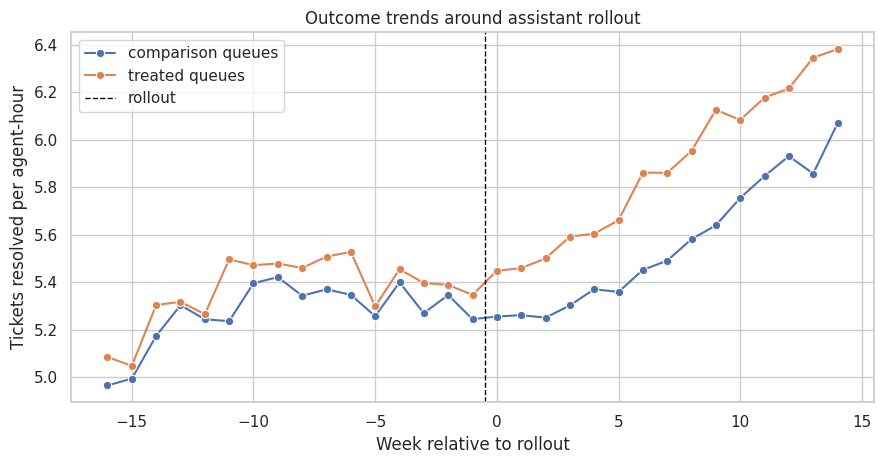

In [8]:
trend = (
    panel
    .groupby(['week', 'treated_queue'], as_index=False)
    .agg(mean_outcome=('tickets_resolved_per_agent_hour', 'mean'))
)
trend['group'] = np.where(trend['treated_queue'] == 1, 'treated queues', 'comparison queues')

plt.figure(figsize=(9, 4.8))
sns.lineplot(data=trend, x='week', y='mean_outcome', hue='group', marker='o')
plt.axvline(-0.5, color='black', linestyle='--', linewidth=1, label='rollout')
plt.title('Outcome trends around assistant rollout')
plt.xlabel('Week relative to rollout')
plt.ylabel('Tickets resolved per agent-hour')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion

The strongest quasi-experiment arguments usually start with simple visuals. If the treated and comparison groups diverged sharply before rollout, an event-study regression will not rescue the design. If the pre-period paths look similar, we still need formal diagnostics and a careful explanation of why timing was plausibly unrelated to counterfactual outcome trends.

## 6. Difference-in-Differences Estimate

The two-way fixed effects DiD regression is

$$
Y_{it} = \alpha_i + \lambda_t + \tau D_{it} + \varepsilon_{it},
$$

where $\alpha_i$ are queue fixed effects, $\lambda_t$ are week fixed effects, and $D_{it}$ equals one for treated queues after rollout.

In [9]:
def fit_did(df, outcome='tickets_resolved_per_agent_hour'):
    formula = f'{outcome} ~ treated_post + C(queue_id) + C(week)'
    model = smf.ols(formula, data=df).fit(cov_type='cluster', cov_kwds={'groups': df['queue_id']})
    coef = model.params['treated_post']
    se = model.bse['treated_post']
    return {
        'formula': formula,
        'estimate': float(coef),
        'cluster_se': float(se),
        'ci_low': float(coef - 1.96 * se),
        'ci_high': float(coef + 1.96 * se),
        'p_value': float(model.pvalues['treated_post']),
        'rows': int(model.nobs),
    }, model

did_result, did_model = fit_did(panel)
did_result

{'formula': 'tickets_resolved_per_agent_hour ~ treated_post + C(queue_id) + C(week)',
 'estimate': 0.22750759300229048,
 'cluster_se': 0.024320791255392115,
 'ci_low': 0.17983884214172194,
 'ci_high': 0.27517634386285905,
 'p_value': 8.403685804250192e-21,
 'rows': 2232}

In [10]:
truth_check = pd.DataFrame(
    [
        {'quantity': 'DiD estimate', 'value': did_result['estimate']},
        {'quantity': 'cluster SE', 'value': did_result['cluster_se']},
        {'quantity': 'true post-period ATT in simulation', 'value': panel.loc[panel['treated_post'] == 1, 'true_effect'].mean()},
        {'quantity': 'estimation error in this simulated draw', 'value': did_result['estimate'] - panel.loc[panel['treated_post'] == 1, 'true_effect'].mean()},
    ]
)
truth_check

,quantity,value
0,DiD estimate,0.227508
1,cluster SE,0.024321
2,true post-period ATT in simulation,0.239938
3,estimation error in this simulated draw,-0.012431


### Discussion

The fixed-effects estimate is only as credible as the design. The regression removes time-invariant queue differences and common calendar shocks, but it does not remove time-varying shocks that differentially affect treated queues. That is why we need pre-trend and placebo diagnostics.

## 7. Event-Study Diagnostics

An event study estimates effects at each relative week. The lead coefficients are especially important. If treatment appears to have an effect before it starts, that is evidence against the design story.

In [11]:
def make_event_study_frame(df, min_event=-8, max_event=10, omit=-1):
    out = df.copy()
    for event_time in range(min_event, max_event + 1):
        if event_time == omit:
            continue
        name = f'event_m{abs(event_time)}' if event_time < 0 else f'event_p{event_time}'
        out[name] = ((out['treated_queue'] == 1) & (out['week'] == event_time)).astype(int)
    return out


def fit_event_study(df, outcome='tickets_resolved_per_agent_hour', min_event=-8, max_event=10, omit=-1):
    es = make_event_study_frame(df, min_event=min_event, max_event=max_event, omit=omit)
    event_cols = [c for c in es.columns if c.startswith('event_')]
    formula = f'{outcome} ~ ' + ' + '.join(event_cols) + ' + C(queue_id) + C(week)'
    model = smf.ols(formula, data=es).fit(cov_type='cluster', cov_kwds={'groups': es['queue_id']})
    rows = []
    for col in event_cols:
        event_time = -int(col.split('m')[1]) if '_m' in col else int(col.split('p')[1])
        coef = model.params[col]
        se = model.bse[col]
        rows.append(
            {
                'event_time': event_time,
                'estimate': float(coef),
                'se': float(se),
                'ci_low': float(coef - 1.96 * se),
                'ci_high': float(coef + 1.96 * se),
                'p_value': float(model.pvalues[col]),
                'period': 'lead' if event_time < 0 else 'lag',
            }
        )
    return pd.DataFrame(rows).sort_values('event_time'), model

event_study, event_model = fit_event_study(panel)
event_study.head(12)

,event_time,estimate,se,ci_low,ci_high,p_value,period
0,-8,-0.056375,0.076386,-0.206093,0.093342,0.460496,lead
1,-7,-0.035311,0.068136,-0.168857,0.098235,0.604285,lead
2,-6,0.007535,0.078128,-0.145596,0.160666,0.923167,lead
3,-5,-0.131987,0.078758,-0.286353,0.022379,0.093767,lead
4,-4,-0.117775,0.075450,-0.265658,0.030107,0.118531,lead
5,-3,-0.046475,0.077606,-0.198582,0.105632,0.549266,lead
6,-2,-0.130694,0.083571,-0.294494,0.033106,0.117850,lead
7,0,0.019524,0.075551,-0.128556,0.167604,0.796081,lag
8,1,0.024792,0.074036,-0.120319,0.169903,0.737729,lag
9,2,0.076215,0.063917,-0.049063,0.201492,0.233105,lag


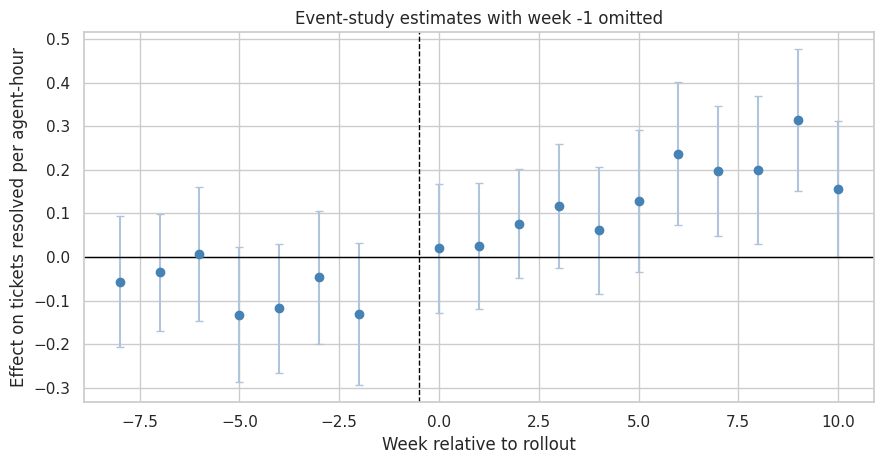

In [12]:
plt.figure(figsize=(9, 4.8))
plt.errorbar(
    event_study['event_time'],
    event_study['estimate'],
    yerr=1.96 * event_study['se'],
    fmt='o',
    color='steelblue',
    ecolor='lightsteelblue',
    capsize=3,
)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(-0.5, color='black', linestyle='--', linewidth=1)
plt.title('Event-study estimates with week -1 omitted')
plt.xlabel('Week relative to rollout')
plt.ylabel('Effect on tickets resolved per agent-hour')
plt.tight_layout()
plt.show()

In [13]:
def pretrend_summary(event_table, alpha=0.05):
    leads = event_table.query('period == "lead"').copy()
    return {
        'lead_coefficients': int(len(leads)),
        'max_abs_lead_estimate': float(leads['estimate'].abs().max()),
        'significant_leads_at_5pct': int((leads['p_value'] < alpha).sum()),
        'mean_abs_lead_estimate': float(leads['estimate'].abs().mean()),
        'status': 'caution' if (leads['p_value'] < alpha).sum() > 0 or leads['estimate'].abs().max() > 0.20 else 'pass',
    }

pretrend = pretrend_summary(event_study)
pretrend

{'lead_coefficients': 7,
 'max_abs_lead_estimate': 0.1319868338564326,
 'significant_leads_at_5pct': 0,
 'mean_abs_lead_estimate': 0.07516470130010165,
 'status': 'pass'}

### Discussion

A pass here does not prove parallel trends. It means we did not find obvious evidence against parallel trends in this simulated diagnostic. A careful report should still discuss timing selection, spillovers, changing ticket mix, and whether the comparison queues are truly untreated.

## 8. Placebo Timing Test

A placebo timing test pretends the rollout happened before it actually did. If the placebo treatment appears to move the outcome in the pre-period, that weakens the design.

In [14]:
def fit_placebo_did(df, placebo_week=-8, outcome='tickets_resolved_per_agent_hour'):
    pre = df.query('week < 0').copy()
    pre['placebo_post'] = (pre['week'] >= placebo_week).astype(int)
    pre['placebo_treated_post'] = pre['treated_queue'] * pre['placebo_post']
    formula = f'{outcome} ~ placebo_treated_post + C(queue_id) + C(week)'
    model = smf.ols(formula, data=pre).fit(cov_type='cluster', cov_kwds={'groups': pre['queue_id']})
    coef = model.params['placebo_treated_post']
    se = model.bse['placebo_treated_post']
    return {
        'placebo_week': placebo_week,
        'estimate': float(coef),
        'cluster_se': float(se),
        'ci_low': float(coef - 1.96 * se),
        'ci_high': float(coef + 1.96 * se),
        'p_value': float(model.pvalues['placebo_treated_post']),
        'status': 'caution' if model.pvalues['placebo_treated_post'] < 0.05 or abs(coef) > 0.20 else 'pass',
    }

placebo_result = fit_placebo_did(panel)
placebo_result

{'placebo_week': -8,
 'estimate': 0.008909107218758285,
 'cluster_se': 0.03222261491042409,
 'ci_low': -0.05424721800567292,
 'ci_high': 0.0720654324431895,
 'p_value': 0.7821746844927735,
 'status': 'pass'}

## 9. Covariate and Composition Diagnostics

Even in panel designs, the composition of work can change. If treated queues receive easier tickets after rollout, a productivity gain may reflect changing ticket mix rather than the assistant.

In [15]:
def did_for_covariate(df, covariate):
    result, _ = fit_did(df, outcome=covariate)
    return {
        'covariate': covariate,
        'did_shift': result['estimate'],
        'cluster_se': result['cluster_se'],
        'p_value': result['p_value'],
        'status': 'caution' if result['p_value'] < 0.05 and abs(result['estimate']) > 0.05 else 'pass',
    }

composition_diagnostics = pd.DataFrame(
    [
        did_for_covariate(panel, 'ticket_complexity'),
        did_for_covariate(panel, 'escalation_rate'),
        did_for_covariate(panel, 'csat_score'),
    ]
)
composition_diagnostics

,covariate,did_shift,cluster_se,p_value,status
0,ticket_complexity,0.013371,0.017131,4.350826e-01,pass
1,escalation_rate,-0.015936,0.001189,6.236287e-41,pass
2,csat_score,0.034775,0.007721,6.668416e-06,pass


### Discussion

Guardrail outcomes are not just product safety checks. In quasi-experiments, they can also reveal design problems. A sudden change in ticket complexity or escalation patterns may indicate that the treated and comparison queues no longer represent comparable work.

## 10. A Small RDD Candidate: Readiness Cutoff

Suppose the rollout was partly determined by a readiness score. Queues above a cutoff were eligible for early enablement. That creates a possible regression-discontinuity design if units near the cutoff are otherwise comparable.

This is not a replacement for the DiD design. It is a candidate design to investigate.

In [16]:
def simulate_readiness_cutoff(n=600, cutoff=0.0, seed=SEED):
    rng = np.random.default_rng(seed)
    score = rng.normal(0, 1, size=n)
    treatment_probability = 0.18 + 0.62 * (score >= cutoff) + 0.08 * rng.normal(size=n)
    treatment_probability = np.clip(treatment_probability, 0.02, 0.98)
    enabled = rng.binomial(1, treatment_probability)
    potential0 = 4.0 + 0.65 * score + 0.20 * score ** 2 + rng.normal(0, 0.45, size=n)
    effect = 0.30 + 0.06 * (score > 0.8)
    outcome = potential0 + effect * enabled
    return pd.DataFrame(
        {
            'readiness_score': score,
            'above_cutoff': (score >= cutoff).astype(int),
            'assistant_enabled': enabled,
            'tickets_resolved_per_agent_hour': outcome,
            'true_effect': effect,
        }
    )

rdd_df = simulate_readiness_cutoff()
rdd_df.head()

,readiness_score,above_cutoff,assistant_enabled,tickets_resolved_per_agent_hour,true_effect
0,1.159879,1,1,5.469699,0.36
1,-0.878066,0,0,3.325596,0.30
2,0.652944,1,1,4.602603,0.30
3,0.088478,1,1,4.821096,0.30
4,0.222932,1,0,4.100876,0.30


In [17]:
def local_rdd(df, bandwidth=0.45, cutoff=0.0):
    local = df.loc[df['readiness_score'].between(cutoff - bandwidth, cutoff + bandwidth)].copy()
    local['running_centered'] = local['readiness_score'] - cutoff
    local['right_x_running'] = local['above_cutoff'] * local['running_centered']
    first_stage = smf.ols('assistant_enabled ~ above_cutoff + running_centered + right_x_running', data=local).fit(cov_type='HC1')
    reduced_form = smf.ols('tickets_resolved_per_agent_hour ~ above_cutoff + running_centered + right_x_running', data=local).fit(cov_type='HC1')
    fuzzy_late = reduced_form.params['above_cutoff'] / first_stage.params['above_cutoff']
    return {
        'bandwidth': bandwidth,
        'rows': int(len(local)),
        'first_stage_jump': float(first_stage.params['above_cutoff']),
        'reduced_form_jump': float(reduced_form.params['above_cutoff']),
        'fuzzy_late': float(fuzzy_late),
        'first_stage_p_value': float(first_stage.pvalues['above_cutoff']),
    }

rdd_results = pd.DataFrame([local_rdd(rdd_df, bandwidth=bw) for bw in [0.25, 0.35, 0.45, 0.60, 0.80]])
rdd_results

,bandwidth,rows,first_stage_jump,reduced_form_jump,fuzzy_late,first_stage_p_value
0,0.25,110,0.456821,-0.067359,-0.147451,2.272532e-03
1,0.35,149,0.539444,-0.155103,-0.287524,5.986317e-05
2,0.45,201,0.572707,-0.180212,-0.314668,8.158948e-07
3,0.60,260,0.584828,-0.082081,-0.140350,4.648440e-09
4,0.80,341,0.598980,-0.037602,-0.062777,8.766477e-13


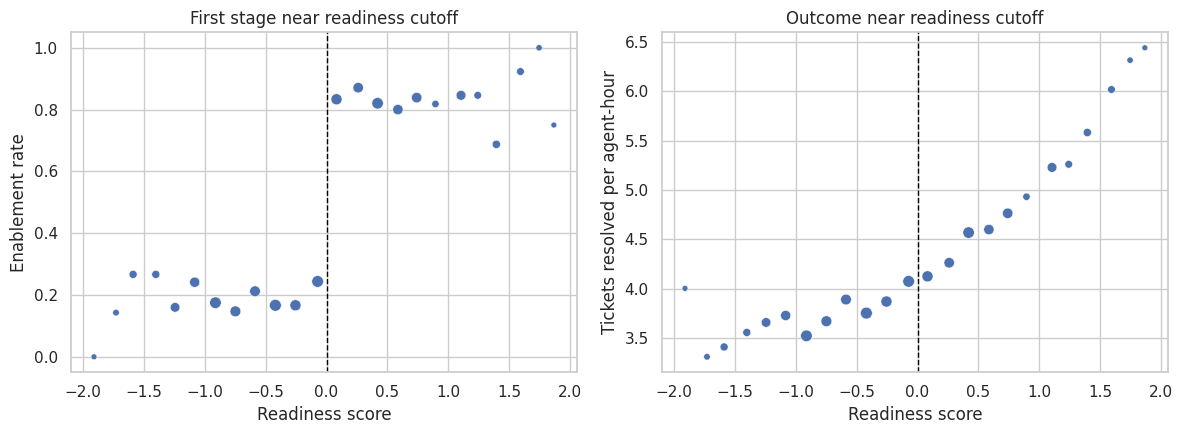

In [18]:
binned = rdd_df.assign(bin=pd.cut(rdd_df['readiness_score'], bins=np.linspace(-2.0, 2.0, 25))).groupby('bin', observed=True).agg(
    score_mid=('readiness_score', 'mean'),
    enable_rate=('assistant_enabled', 'mean'),
    outcome=('tickets_resolved_per_agent_hour', 'mean'),
    n=('assistant_enabled', 'size'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=binned, x='score_mid', y='enable_rate', size='n', legend=False, ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('First stage near readiness cutoff')
axes[0].set_xlabel('Readiness score')
axes[0].set_ylabel('Enablement rate')

sns.scatterplot(data=binned, x='score_mid', y='outcome', size='n', legend=False, ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Outcome near readiness cutoff')
axes[1].set_xlabel('Readiness score')
axes[1].set_ylabel('Tickets resolved per agent-hour')
plt.tight_layout()
plt.show()

In [19]:
def cutoff_density_check(df, cutoff=0.0, bandwidth=0.20):
    left = ((df['readiness_score'] >= cutoff - bandwidth) & (df['readiness_score'] < cutoff)).sum()
    right = ((df['readiness_score'] >= cutoff) & (df['readiness_score'] <= cutoff + bandwidth)).sum()
    expected = (left + right) / 2
    z = (right - expected) / np.sqrt(expected) if expected > 0 else np.nan
    return {
        'left_count': int(left),
        'right_count': int(right),
        'right_left_ratio': float(right / left) if left else np.nan,
        'rough_z': float(z),
        'status': 'caution' if abs(z) > 2.0 else 'pass',
    }

rdd_density = cutoff_density_check(rdd_df)
rdd_density

{'left_count': 45,
 'right_count': 38,
 'right_left_ratio': 0.8444444444444444,
 'rough_z': -0.543305367994433,
 'status': 'pass'}

### Discussion

The RDD candidate requires a different assumption from DiD. We need continuity at the cutoff, no precise manipulation of the running variable, and no other discontinuous policy changes at the same threshold. AI can help list those concerns, but the analyst must test density, covariates, bandwidth sensitivity, and institutional details.

## 11. A Design Scorecard

We now combine the deterministic diagnostics into a scorecard. This is not a universal validity score. It is a compact way to force the AI reviewer to confront the evidence.

In [20]:
def classify_quasi_design(did, pretrend, placebo, composition, rdd_density):
    gates = []
    gates.append({'gate': 'DiD estimate precision', 'status': 'pass' if did['p_value'] < 0.05 else 'caution', 'detail': f"p={did['p_value']:.3f}"})
    gates.append({'gate': 'event-study pre-trends', 'status': pretrend['status'], 'detail': f"significant leads={pretrend['significant_leads_at_5pct']}"})
    gates.append({'gate': 'placebo timing', 'status': placebo['status'], 'detail': f"placebo estimate={placebo['estimate']:.3f}"})
    composition_status = 'caution' if (composition['status'] == 'caution').any() else 'pass'
    gates.append({'gate': 'composition and guardrail shifts', 'status': composition_status, 'detail': f"caution rows={(composition['status'] == 'caution').sum()}"})
    gates.append({'gate': 'RDD density manipulation screen', 'status': rdd_density['status'], 'detail': f"right/left={rdd_density['right_left_ratio']:.2f}"})
    gate_table = pd.DataFrame(gates)
    if (gate_table['status'] == 'caution').sum() >= 2:
        recommendation = 'needs_more_design_work'
    elif (gate_table['status'] == 'caution').sum() == 1:
        recommendation = 'credible_with_checks'
    else:
        recommendation = 'credible_with_checks'
    return gate_table, recommendation

quasi_gate_table, deterministic_recommendation = classify_quasi_design(
    did_result,
    pretrend,
    placebo_result,
    composition_diagnostics,
    rdd_density,
)
display(quasi_gate_table)
print('Deterministic recommendation:', deterministic_recommendation)

,gate,status,detail
0,DiD estimate precision,pass,p=0.000
1,event-study pre-trends,pass,significant leads=0
2,placebo timing,pass,placebo estimate=0.009
3,composition and guardrail shifts,pass,caution rows=0
4,RDD density manipulation screen,pass,right/left=0.84


Deterministic recommendation: credible_with_checks


## 12. Machine-Readable Quasi-Experiment Report

The report below is what we give to the LLM. Notice that it includes design assumptions and diagnostics, not just estimates.

In [21]:
def dataframe_records(df, digits=6):
    return json.loads(df.round(digits).to_json(orient='records'))

quasi_report = {
    'quasi_contract': quasi_contract,
    'did_result': did_result,
    'truth_available_only_because_synthetic': {
        'true_post_period_att': float(panel.loc[panel['treated_post'] == 1, 'true_effect'].mean()),
        'note': 'This is visible only because the notebook uses synthetic teaching data.',
    },
    'event_study_summary': pretrend,
    'event_study_leads': dataframe_records(event_study.query('period == "lead"')),
    'event_study_lags': dataframe_records(event_study.query('period == "lag"').head(6)),
    'placebo_timing_test': placebo_result,
    'composition_diagnostics': dataframe_records(composition_diagnostics),
    'rdd_candidate': {
        'description': 'Readiness-score cutoff for early assistant eligibility.',
        'bandwidth_sensitivity': dataframe_records(rdd_results),
        'density_check': rdd_density,
    },
    'design_gate_table': dataframe_records(quasi_gate_table),
    'deterministic_recommendation': deterministic_recommendation,
    'brittleness_note': 'Quasi-experiment credibility depends on design assumptions; LLM outputs and simulated diagnostics can vary across reruns.',
}

print(json.dumps(quasi_report, indent=2)[:5000])

{
  "quasi_contract": {
    "analysis_id": "ai_support_staged_rollout_did_v1",
    "business_question": "What is the effect of enabling an AI support assistant on tickets resolved per agent-hour?",
    "candidate_design": "difference-in-differences with event-study diagnostics",
    "unit": "support_queue_week",
    "treated_unit": "support queue",
    "treatment": "assistant enabled for first-draft support responses",
    "comparison": "queues not yet enabled during the same calendar weeks",
    "time_zero": "first week the assistant is enabled for treated queues",
    "primary_outcome": "tickets_resolved_per_agent_hour",
    "guardrail_outcomes": [
      "escalation_rate",
      "csat_score"
    ],
    "pre_period_weeks": 16,
    "post_period_weeks": 14,
    "key_assumption": "treated and comparison queues would have followed parallel trends absent assistant enablement",
    "known_risks": [
      "Queues were prioritized partly by operational readiness.",
      "Agents may move acro

## 13. Optional AI Quasi-Experiment Review

The model's job is to review the design, not to declare causality. A good answer should discuss identification assumptions, diagnostics, threats, and missing institutional facts.

In [22]:
def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


In [23]:
class QuasiExperimentReview(BaseModel):
    design_summary: str = Field(description='Brief summary of proposed quasi-experiment.')
    candidate_design_assessment: list[str] = Field(description='Assessment of DiD, event study, RDD, IV, or synthetic-control candidates.')
    identifying_assumption_assessment: list[str] = Field(description='Assessment of the core identifying assumptions.')
    diagnostics_assessment: list[str] = Field(description='Assessment of pre-trends, placebos, RDD checks, and composition checks.')
    threats_to_validity: list[str] = Field(description='Remaining threats such as spillovers, endogenous timing, manipulation, and measurement changes.')
    recommendation: Literal['credible_with_checks', 'needs_more_design_work', 'not_credible'] = Field(description='Recommended design posture.')
    recommendation_rationale: list[str] = Field(description='Reasons for the recommendation.')
    next_checks: list[str] = Field(description='Concrete checks or data work to run next.')
    stakeholder_summary: str = Field(description='Plain-language summary for stakeholders.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the review.')

REVIEW_SCALAR_FIELDS = ['design_summary', 'recommendation', 'stakeholder_summary', 'confidence']
REVIEW_LIST_FIELDS = [
    'candidate_design_assessment',
    'identifying_assumption_assessment',
    'diagnostics_assessment',
    'threats_to_validity',
    'recommendation_rationale',
    'next_checks',
]
REVIEW_ALIASES = {
    'summary': 'design_summary',
    'designs': 'candidate_design_assessment',
    'candidate_designs': 'candidate_design_assessment',
    'assumptions': 'identifying_assumption_assessment',
    'diagnostics': 'diagnostics_assessment',
    'threats': 'threats_to_validity',
    'risks': 'threats_to_validity',
    'rationale': 'recommendation_rationale',
    'checks': 'next_checks',
}
REVIEW_VALUE_ALIASES = {
    'recommendation': {
        'credible_with_checks': 'credible_with_checks',
        'crediblewithchecks': 'credible_with_checks',
        'credible': 'credible_with_checks',
        'proceed_with_checks': 'credible_with_checks',
        'needs_more_design_work': 'needs_more_design_work',
        'needsmoredesignwork': 'needs_more_design_work',
        'needs_work': 'needs_more_design_work',
        'revise': 'needs_more_design_work',
        'not_credible': 'not_credible',
        'notcredible': 'not_credible',
        'invalid': 'not_credible',
        'do_not_use': 'not_credible',
    },
    'confidence': {'low': 'low', 'medium': 'medium', 'moderate': 'medium', 'high': 'high'},
}
REVIEW_DEFAULTS = {
    'design_summary': '',
    'candidate_design_assessment': [],
    'identifying_assumption_assessment': [],
    'diagnostics_assessment': [],
    'threats_to_validity': [],
    'recommendation_rationale': [],
    'next_checks': [],
    'stakeholder_summary': '',
    'confidence': 'medium',
}


def parse_quasi_review(raw_output):
    result = parse_pydantic_output(
        raw_output,
        QuasiExperimentReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=REVIEW_DEFAULTS,
    )
    return result.parsed, result.json_text, result.notes

In [24]:
SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference quasi-experiment reviewer.\n'
    'Rules:\n'
    '- Use only the provided quasi-experiment report.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Do not claim the quasi-experiment proves causality.\n'
    '- Discuss DiD/event-study assumptions, pre-trends, placebo timing, composition shifts, RDD checks, spillovers, and endogenous timing.\n'
    '- Do not treat synthetic truth fields as available in real data.\n'
    '- Mention brittleness and rerun/model-output instability where appropriate.\n'
)


def build_review_prompt(report):
    schema_hint = {
        'design_summary': 'string',
        'candidate_design_assessment': ['string'],
        'identifying_assumption_assessment': ['string'],
        'diagnostics_assessment': ['string'],
        'threats_to_validity': ['string'],
        'recommendation': 'credible_with_checks | needs_more_design_work | not_credible',
        'recommendation_rationale': ['string'],
        'next_checks': ['string'],
        'stakeholder_summary': 'string',
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a QuasiExperimentReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {json.dumps(schema_hint, indent=2)}

        Quasi-experiment report:
        {json.dumps(report, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(quasi_report)
print(review_prompt[:3000])

Produce a QuasiExperimentReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {
  "design_summary": "string",
  "candidate_design_assessment": [
    "string"
  ],
  "identifying_assumption_assessment": [
    "string"
  ],
  "diagnostics_assessment": [
    "string"
  ],
  "threats_to_validity": [
    "string"
  ],
  "recommendation": "credible_with_checks | needs_more_design_work | not_credible",
  "recommendation_rationale": [
    "string"
  ],
  "next_checks": [
    "string"
  ],
  "stakeholder_summary": "string",
  "confidence": "low | medium | high"
}

        Quasi-experiment report:
        {
  "quasi_contract": {
    "analysis_id": "ai_support_staged_rollout_did_v1",
    "business_question": "What is the effect of enabling an AI support assistant on tickets resolved per agent-hour?",
    "candidate_design": "difference-in-differen

In [25]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    display(Markdown('### Raw model output'))
    display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "design_summary": "The study employs a difference-in-differences (DiD) approach to evaluate the impact of enabling an AI support assistant on tickets resolved per agent-hour. Event-study diagnostics are used to assess pre-trends and potential dynamics around the treatment time. The analysis includes guardrail outcomes such as escalation rate and CSAT score to monitor unintended consequences.",
 "candidate_design_assessment": [
 "Difference-in-differences with event-study diagnostics is a suitable design for evaluating the impact of the AI assistant.",
 "Event-study diagnostics help validate the parallel trends assumption before and after the treatment.",
 "Guardrail outcomes provide additional context on the overall impact of the intervention."
 ],
 "identifying_assumption_assessment": [
 "Parallel trends assumption: Treated and comparison groups should have followed similar trends in the absence of the treatment.",
 "No anticipation effects: There should be no significant changes in the outcome variable in the lead-up to the treatment period.",
 "No post-treatment interference: The treatment should not affect the comparison group after the treatment period."
 ],
 "diagnostics_assessment": [
 "Pre-trends: The event-study results show no significant changes in the lead-up to the treatment period, supporting the parallel trends assumption.",
 "Placebo test: A placebo test at -8 weeks did not show any significant effect, indicating that the observed effect is not due to random fluctuations.",
 "Composition shifts: Key covariates like ticket complexity, escalation rate, and CSAT score did not significantly shift between the treated and comparison groups, suggesting stable compositions.",
 "RDD checks: The regression discontinuity design (RDD) analysis shows consistent results across different bandwidths, with strong first-stage jumps and reduced-form estimates."
 ],
 "threats_to_validity": [
 "Operational readiness: Queues were prioritized based on operational readiness, which could introduce selection bias.",
 "Agent mobility: Agents moving across queues might cause spillover effects, affecting the validity of the comparison groups.",
 "Seasonality and ticket mix: Differences in seasonality and ticket mix between queues could confound the results.",
 "Endogenous timing: The timing of assistant enablement might not be exogenous, potentially leading to biased estimates."
 ],
 "recommendation": "credible_with_checks",
 "recommendation_rationale": [
 "The DiD estimate is statistically significant and robust to placebo tests.",
 "Event-study diagnostics indicate no significant pre-trends.",
 "Composition diagnostics show no significant shifts in key covariates.",
 "RDD checks suggest a plausible cutoff point for treatment assignment."
 ],
 "next_checks": [
 "Conduct sensitivity analyses to explore the robustness of the DiD estimate under different model specifications.",
 "Further investigate potential spillover effects by analyzing agent-level data.",
 "Examine the impact of seasonality and ticket mix on the results.",
 "Assess the stability of the RDD results across different bandwidths and sample sizes."
 ],
 "stakeholder_summary": "The study finds a positive and significant effect of enabling an AI support assistant on tickets resolved per agent-hour. However, several threats to validity need further investigation to ensure the credibility of the findings.",
 "confidence": "medium"
}
```

In [26]:
if raw_review_output:
    try:
        quasi_review, quasi_review_json, review_parser_notes = parse_quasi_review(raw_review_output)
        single_model_parse_error = ''
        display(Markdown('### Parsed quasi-experiment review'))
        display(Markdown(f'```json\n{quasi_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        quasi_review = None
        quasi_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    quasi_review = None
    quasi_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

### Parsed quasi-experiment review

```json
{
  "design_summary": "The study employs a difference-in-differences (DiD) approach to evaluate the impact of enabling an AI support assistant on tickets resolved per agent-hour. Event-study diagnostics are used to assess pre-trends and potential dynamics around the treatment time. The analysis includes guardrail outcomes such as escalation rate and CSAT score to monitor unintended consequences.",
  "candidate_design_assessment": [
    "Difference-in-differences with event-study diagnostics is a suitable design for evaluating the impact of the AI assistant.",
    "Event-study diagnostics help validate the parallel trends assumption before and after the treatment.",
    "Guardrail outcomes provide additional context on the overall impact of the intervention."
  ],
  "identifying_assumption_assessment": [
    "Parallel trends assumption: Treated and comparison groups should have followed similar trends in the absence of the treatment.",
    "No anticipation effects: There should be no significant changes in the outcome variable in the lead-up to the treatment period.",
    "No post-treatment interference: The treatment should not affect the comparison group after the treatment period."
  ],
  "diagnostics_assessment": [
    "Pre-trends: The event-study results show no significant changes in the lead-up to the treatment period, supporting the parallel trends assumption.",
    "Placebo test: A placebo test at -8 weeks did not show any significant effect, indicating that the observed effect is not due to random fluctuations.",
    "Composition shifts: Key covariates like ticket complexity, escalation rate, and CSAT score did not significantly shift between the treated and comparison groups, suggesting stable compositions.",
    "RDD checks: The regression discontinuity design (RDD) analysis shows consistent results across different bandwidths, with strong first-stage jumps and reduced-form estimates."
  ],
  "threats_to_validity": [
    "Operational readiness: Queues were prioritized based on operational readiness, which could introduce selection bias.",
    "Agent mobility: Agents moving across queues might cause spillover effects, affecting the validity of the comparison groups.",
    "Seasonality and ticket mix: Differences in seasonality and ticket mix between queues could confound the results.",
    "Endogenous timing: The timing of assistant enablement might not be exogenous, potentially leading to biased estimates."
  ],
  "recommendation": "credible_with_checks",
  "recommendation_rationale": [
    "The DiD estimate is statistically significant and robust to placebo tests.",
    "Event-study diagnostics indicate no significant pre-trends.",
    "Composition diagnostics show no significant shifts in key covariates.",
    "RDD checks suggest a plausible cutoff point for treatment assignment."
  ],
  "next_checks": [
    "Conduct sensitivity analyses to explore the robustness of the DiD estimate under different model specifications.",
    "Further investigate potential spillover effects by analyzing agent-level data.",
    "Examine the impact of seasonality and ticket mix on the results.",
    "Assess the stability of the RDD results across different bandwidths and sample sizes."
  ],
  "stakeholder_summary": "The study finds a positive and significant effect of enabling an AI support assistant on tickets resolved per agent-hour. However, several threats to validity need further investigation to ensure the credibility of the findings.",
  "confidence": "medium"
}
```

Parser notes: []


## 14. Auditing the AI Review

The audit checks whether the model noticed the main design issues. This is not a perfect evaluator; it is a guardrail against fluent overclaiming.

In [27]:
def review_text(review):
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    return any(term.lower() in text for term in terms)


def recommendation_not_too_optimistic(model_rec, expected_rec):
    order = {'credible_with_checks': 0, 'needs_more_design_work': 1, 'not_credible': 2}
    return order.get(model_rec, -1) >= order.get(expected_rec, 0)


def score_quasi_review(review, report, expected_rec):
    text = review_text(review)
    recommendation = review.recommendation if review is not None else ''
    checks = {
        'mentions DiD or event study': contains_any(text, ['difference-in-differences', 'did', 'event study', 'event-study']),
        'mentions parallel trends': contains_any(text, ['parallel trend', 'pre-trend', 'pretrend']),
        'mentions placebo timing': contains_any(text, ['placebo', 'fake rollout', 'timing']),
        'mentions composition or guardrails': contains_any(text, ['composition', 'ticket complexity', 'escalation', 'csat', 'guardrail']),
        'mentions RDD cutoff assumptions': contains_any(text, ['rdd', 'regression discontinuity', 'cutoff', 'density', 'manipulation']),
        'mentions endogenous timing or readiness': contains_any(text, ['endogenous', 'timing', 'readiness', 'selection']),
        'mentions spillovers or interference': contains_any(text, ['spillover', 'interference', 'agents move', 'contamination']),
        'does not treat synthetic truth as real evidence': not contains_any(text, ['oracle proves', 'synthetic truth confirms for real data']),
        'recommendation not too optimistic': recommendation_not_too_optimistic(recommendation, expected_rec),
        'mentions brittleness or rerun instability': contains_any(text, ['brittle', 'rerun', 'unstable', 'simulation', 'model output']),
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit)

expected_recommendation = quasi_report['deterministic_recommendation']

if quasi_review is not None:
    single_audit, single_score, single_max_score = score_quasi_review(quasi_review, quasi_report, expected_recommendation)
    print(f'Expected recommendation from deterministic gates: {expected_recommendation}')
    print(f'Score: {single_score}/{single_max_score}')
    display(single_audit)
else:
    print('No quasi-experiment review to audit because live model execution was skipped or parsing failed.')

Expected recommendation from deterministic gates: credible_with_checks
Score: 9/10


,check,passed,credit
0,mentions DiD or event study,True,1
1,mentions parallel trends,True,1
2,mentions placebo timing,True,1
3,mentions composition or guardrails,True,1
4,mentions RDD cutoff assumptions,True,1
5,mentions endogenous timing or readiness,True,1
6,mentions spillovers or interference,True,1
7,does not treat synthetic truth as real evidence,True,1
8,recommendation not too optimistic,True,1
9,mentions brittleness or rerun instability,False,0


## 15. Optional All-Model Comparison

For cross-model comparison, we use a compact decision schema. This keeps the benchmark focused on quasi-experiment judgment rather than long-form report writing.

In [28]:
def build_quasi_report_variant(case_id, pretrend_gap=0.0, anticipation_effect=0.0, seed=SEED):
    variant_panel = simulate_support_rollout(pretrend_gap=pretrend_gap, anticipation_effect=anticipation_effect, seed=seed)
    variant_did, _ = fit_did(variant_panel)
    variant_event, _ = fit_event_study(variant_panel)
    variant_pretrend = pretrend_summary(variant_event)
    variant_placebo = fit_placebo_did(variant_panel)
    variant_composition = pd.DataFrame(
        [
            did_for_covariate(variant_panel, 'ticket_complexity'),
            did_for_covariate(variant_panel, 'escalation_rate'),
            did_for_covariate(variant_panel, 'csat_score'),
        ]
    )
    variant_gates, variant_rec = classify_quasi_design(variant_did, variant_pretrend, variant_placebo, variant_composition, rdd_density)
    return {
        'case_id': case_id,
        'quasi_contract': quasi_contract,
        'did_result': variant_did,
        'event_study_summary': variant_pretrend,
        'placebo_timing_test': variant_placebo,
        'composition_diagnostics': dataframe_records(variant_composition),
        'rdd_candidate': {'density_check': rdd_density, 'bandwidth_sensitivity': dataframe_records(rdd_results)},
        'design_gate_table': dataframe_records(variant_gates),
        'deterministic_recommendation': variant_rec,
        'brittleness_note': 'This comparison uses simulated variants; model rankings and simulation diagnostics can move across reruns.',
    }

QUASI_EVAL_CASES = [
    {'case_id': 'credible_parallel_trends_case', 'report': build_quasi_report_variant('credible_parallel_trends_case', pretrend_gap=0.0, anticipation_effect=0.0, seed=SEED + 11)},
    {'case_id': 'bad_pretrend_case', 'report': build_quasi_report_variant('bad_pretrend_case', pretrend_gap=0.40, anticipation_effect=0.0, seed=SEED + 22)},
    {'case_id': 'anticipation_case', 'report': build_quasi_report_variant('anticipation_case', pretrend_gap=0.0, anticipation_effect=0.35, seed=SEED + 33)},
]
for case in QUASI_EVAL_CASES:
    case['expected_recommendation'] = case['report']['deterministic_recommendation']

pd.DataFrame([{k: v for k, v in case.items() if k != 'report'} for case in QUASI_EVAL_CASES])

,case_id,expected_recommendation
0,credible_parallel_trends_case,credible_with_checks
1,bad_pretrend_case,credible_with_checks
2,anticipation_case,credible_with_checks


In [29]:
SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'expected_recommendation', 'model_recommendation', 'status',
    'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'review_score', 'max_review_score',
    'review_score_share', 'error', 'raw_output_preview'
]

class QuasiExperimentDecision(BaseModel):
    design_summary: str = Field(description='One-sentence design summary.')
    key_risk_signals: list[str] = Field(description='Most important identifying-assumption or diagnostic signals.')
    recommendation: Literal['credible_with_checks', 'needs_more_design_work', 'not_credible'] = Field(description='Recommended design posture.')
    recommendation_rationale: list[str] = Field(description='Reasons for the recommendation.')
    next_checks: list[str] = Field(description='Concrete next checks.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the recommendation.')

DECISION_SCALAR_FIELDS = ['design_summary', 'recommendation', 'confidence']
DECISION_LIST_FIELDS = ['key_risk_signals', 'recommendation_rationale', 'next_checks']
DECISION_ALIASES = {'summary': 'design_summary', 'risks': 'key_risk_signals', 'signals': 'key_risk_signals', 'rationale': 'recommendation_rationale', 'checks': 'next_checks'}
DECISION_DEFAULTS = {'design_summary': '', 'key_risk_signals': [], 'recommendation_rationale': [], 'next_checks': [], 'confidence': 'medium'}

DECISION_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required QuasiExperimentDecision JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.
    Use exact enum strings from the schema. Keep missing non-critical list fields as empty arrays.

    Required schema:
    {
      "design_summary": "string",
      "key_risk_signals": ["string"],
      "recommendation": "credible_with_checks | needs_more_design_work | not_credible",
      "recommendation_rationale": ["string"],
      "next_checks": ["string"],
      "confidence": "low | medium | high"
    }

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def compact_quasi_report(report):
    return {
        'case_id': report.get('case_id', 'single_design'),
        'candidate_design': report['quasi_contract']['candidate_design'],
        'key_assumption': report['quasi_contract']['key_assumption'],
        'did_result': report['did_result'],
        'event_study_summary': report['event_study_summary'],
        'placebo_timing_test': report['placebo_timing_test'],
        'composition_diagnostics': report['composition_diagnostics'],
        'rdd_density_check': report['rdd_candidate']['density_check'],
        'design_gate_table': report['design_gate_table'],
        'deterministic_recommendation': report['deterministic_recommendation'],
        'brittleness_note': report['brittleness_note'],
    }


def build_decision_prompt(report):
    schema_hint = {
        'design_summary': 'string',
        'key_risk_signals': ['string'],
        'recommendation': 'credible_with_checks | needs_more_design_work | not_credible',
        'recommendation_rationale': ['string'],
        'next_checks': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce one compact QuasiExperimentDecision JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only. Keep each list to 2-4 concise strings.
        {json.dumps(schema_hint, indent=2)}

        Compact quasi-experiment report:
        {json.dumps(compact_quasi_report(report), indent=2)}
        '''
    ).strip()


def parse_quasi_decision(raw_output):
    result = parse_pydantic_output(
        raw_output,
        QuasiExperimentDecision,
        scalar_fields=DECISION_SCALAR_FIELDS,
        list_fields=DECISION_LIST_FIELDS,
        field_aliases=DECISION_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=DECISION_DEFAULTS,
    )
    return result.parsed, result.json_text, result.notes


def classify_structured_output_failure(error):
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_quasi_decision():
    return QuasiExperimentDecision(design_summary='', key_risk_signals=[], recommendation='needs_more_design_work', recommendation_rationale=[], next_checks=[], confidence='low')


def decision_to_review(decision):
    return QuasiExperimentReview(
        design_summary=decision.design_summary,
        candidate_design_assessment=decision.key_risk_signals,
        identifying_assumption_assessment=decision.key_risk_signals,
        diagnostics_assessment=decision.key_risk_signals,
        threats_to_validity=decision.key_risk_signals,
        recommendation=decision.recommendation,
        recommendation_rationale=decision.recommendation_rationale,
        next_checks=decision.next_checks,
        stakeholder_summary=decision.design_summary,
        confidence=decision.confidence,
    )


def parse_or_repair_decision(raw_output, model_id):
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_quasi_decision(raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': notes, 'repair_used': bool(notes), 'repair_stage': 'parser' if notes else 'none', 'repaired_raw_output': ''}
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = DECISION_REPAIR_PROMPT_TEMPLATE.format(raw_output=clean_generated_text(raw_output)[:5000], error_message=clean_generated_text(repr(first_error))[:1200])
        repaired_raw_output = local_chat(repair_prompt, system_message=SYSTEM_REVIEW_MESSAGE, model_id=model_id, max_new_tokens=900, temperature=TEMPERATURE)
        parsed, parsed_json, notes = parse_quasi_decision(repaired_raw_output)
        return {'parsed': parsed, 'parsed_json': parsed_json, 'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes, 'repair_used': True, 'repair_stage': 'model_retry', 'repaired_raw_output': repaired_raw_output}


def run_single_model_quasi_case(label, model_id, role, case):
    prompt = build_decision_prompt(case['report'])
    raw_output = ''
    max_score = score_quasi_review(decision_to_review(empty_quasi_decision()), case['report'], case['expected_recommendation'])[2]
    try:
        raw_output = local_chat(prompt, system_message=SYSTEM_REVIEW_MESSAGE, model_id=model_id, max_new_tokens=900, temperature=TEMPERATURE)
        parsed_result = parse_or_repair_decision(raw_output, model_id)
        review_proxy = decision_to_review(parsed_result['parsed'])
        audit, score, max_score = score_quasi_review(review_proxy, case['report'], case['expected_recommendation'])
        return {'label': label, 'model_id': model_id, 'role': role, 'case_id': case['case_id'], 'expected_recommendation': case['expected_recommendation'], 'model_recommendation': parsed_result['parsed'].recommendation, 'status': 'ok', 'schema_valid': True, 'repair_used': parsed_result['repair_used'], 'repair_stage': parsed_result['repair_stage'], 'error_type': '', 'review_score': score, 'max_review_score': max_score, 'review_score_share': score / max_score if max_score else 0.0, 'error': '', 'raw_output_preview': clean_generated_text(raw_output)[:500]}
    except Exception as error:
        return {'label': label, 'model_id': model_id, 'role': role, 'case_id': case['case_id'], 'expected_recommendation': case['expected_recommendation'], 'model_recommendation': '', 'status': 'failed', 'schema_valid': False, 'repair_used': False, 'repair_stage': 'failed', 'error_type': classify_structured_output_failure(error), 'review_score': 0, 'max_review_score': max_score, 'review_score_share': 0.0, 'error': clean_generated_text(repr(error))[:900], 'raw_output_preview': clean_generated_text(raw_output)[:500]}


def summarize_model_results(case_results):
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = case_results.groupby(['label', 'model_id', 'role'], as_index=False).agg(
        cases=('case_id', 'count'),
        schema_valid_cases=('schema_valid', 'sum'),
        schema_repaired_cases=('repair_used', 'sum'),
        mean_review_score=('review_score_share', 'mean'),
        failure_types=('error_type', lambda values: sorted({value for value in values if value})),
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_quasi_comparison(models_to_compare=MODELS_TO_COMPARE, cases=QUASI_EVAL_CASES):
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_quasi_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    quasi_model_summary, quasi_case_results = run_all_model_quasi_comparison()
else:
    quasi_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    quasi_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

quasi_model_summary

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct
Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct
Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct
Running Phi mini: microsoft/Phi-3.5-mini-instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3
Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it
Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,2,2,2,1.0,0.95,[]
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,2,2,0,1.0,0.85,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,2,2,0,1.0,0.85,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,2,2,2,1.0,0.80,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,2,2,0,1.0,0.80,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,2,2,0,1.0,0.80,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,2,2,0,1.0,0.80,[]
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,2,2,2,1.0,0.75,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,2,2,2,1.0,0.75,[]


In [30]:
if not quasi_case_results.empty:
    quasi_case_results[[
        'label',
        'case_id',
        'expected_recommendation',
        'model_recommendation',
        'review_score_share',
        'status',
        'error_type',
    ]].sort_values(['label', 'case_id']).head(30)
else:
    print('No model-comparison case results yet.')

In [31]:
if not quasi_case_results.empty:
    failed_model_details = quasi_case_results.loc[
        ~quasi_case_results['schema_valid'],
        ['label', 'case_id', 'status', 'error_type', 'error', 'raw_output_preview'],
    ].reset_index(drop=True)
    failed_model_details
else:
    print('No failed model details because the full comparison was skipped.')

In [32]:
def summarize_repair_stages(case_results):
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(quasi_case_results)

,repair_stage,cases
0,none,10
1,parser,8


## 16. Reusable Quasi-Experiment Checklist

A quasi-experiment review should be boringly systematic. Use the checklist below before writing a causal claim.

In [33]:
quasi_experiment_checklist = pd.DataFrame(
    [
        {'area': 'Assignment story', 'check': 'Explain exactly why treatment timing or intensity changed.'},
        {'area': 'Comparison group', 'check': 'Show why comparison units are plausible counterfactuals.'},
        {'area': 'Pre-trends', 'check': 'Plot and estimate pre-treatment leads.'},
        {'area': 'Placebo tests', 'check': 'Run fake timing, fake outcomes, or fake treated-unit checks.'},
        {'area': 'Composition', 'check': 'Check whether population, work mix, or measurement changed at treatment.'},
        {'area': 'Spillovers', 'check': 'Assess whether untreated units were indirectly exposed.'},
        {'area': 'Design alternatives', 'check': 'Consider RDD, IV, or synthetic control if the assignment story supports them.'},
        {'area': 'Communication', 'check': 'State assumptions and threats as part of the result.'},
        {'area': 'AI guardrail', 'check': 'Treat LLM reviews as draft artifacts; schema-check, score, and human-review them.'},
    ]
)
quasi_experiment_checklist

,area,check
0,Assignment story,Explain exactly why treatment timing or intensity changed.
1,Comparison group,Show why comparison units are plausible counterfactuals.
2,Pre-trends,Plot and estimate pre-treatment leads.
3,Placebo tests,"Run fake timing, fake outcomes, or fake treated-unit checks."
4,Composition,"Check whether population, work mix, or measurement changed at treatment."
5,Spillovers,Assess whether untreated units were indirectly exposed.
6,Design alternatives,"Consider RDD, IV, or synthetic control if the assignment story supports them."
7,Communication,State assumptions and threats as part of the result.
8,AI guardrail,"Treat LLM reviews as draft artifacts; schema-check, score, and human-review them."


## 17. Exercises

1. Increase `pretrend_gap` in the simulation. How do the event-study leads change?
2. Add an anticipation effect in weeks -2 and -1. Does the placebo timing test detect it?
3. Change the treated share from 45 percent to 20 percent. What happens to precision?
4. Make ticket complexity jump after rollout for treated queues. How should the design report change?
5. Modify the RDD simulation so the density near the cutoff is manipulated. What warning should appear?
6. Rerun the live LLM review. Did the model distinguish DiD assumptions from RDD assumptions?
7. Compare models on the two benchmark cases. Which failures are schema failures, and which are design-reasoning failures?

## 18. Key Takeaways

Quasi-experiments are not weaker because they are non-randomized; they are weaker when their design story is vague. A credible quasi-experiment makes the source of variation explicit and exposes the assumptions to diagnostic pressure.

The most important lessons are:

- DiD depends on counterfactual trends, not just before/after comparisons.
- Event-study leads are design diagnostics, not decorative plots.
- Placebo and composition checks are central to quasi-experiment credibility.
- RDD, IV, and synthetic control are candidates only when the assignment mechanism supports them.
- LLMs can help brainstorm and critique designs, but they can also overclaim. Use structured reports, deterministic diagnostics, model comparison, and human review.